# Apply Neural Networks for Classification

We apply a simple neural network to Bank Customer Churn Prediction binary classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('../datasets/Bank Customer Churn Prediction.csv')
#df.dtypes
one_hot_country = pd.get_dummies(df.country, prefix='country')
one_hot_gender = pd.get_dummies(df.gender, prefix='gender')
df = df.drop(["country","gender"],axis=1)
df = pd.concat([df, one_hot_country, one_hot_gender], axis=1)

df = df.drop(['customer_id'], axis='columns')
X = df.drop(['churn'], axis='columns')
y = df['churn']

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [2]:
df

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_France,country_Germany,country_Spain,gender_Female,gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,True,False,False,True,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,False,True,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,True,False,False,True,False
3,699,39,1,0.00,2,0,0,93826.63,0,True,False,False,True,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,True,False,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,True,False,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,True,False,False,True,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,False,True,False,False,True


In [3]:
X_train.shape

(8000, 13)

## Network 1
The network outputs a single activation node (it is a binary classification) with sigmoid activation.
It means the network outputs a (0,1) value. The is the probability of the class being class = 1

![](figures/neural1.png)

In [4]:
from keras.models import Sequential
from keras.layers import Dense, Input


model = Sequential([
Input(shape=(X_train.shape[1],)),

Dense(30, activation="relu"),
Dense(30, activation="relu"),

Dense(1, activation="sigmoid")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,381 (5.39 KB)

 Trainable params: 1,381 (5.39 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
#model.compile(loss='binary_crossentropy', optimizer='adam')

# I want to compute the accuracy while training

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


history = model.fit(X_train, y_train, epochs=100, validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7779 - loss: 0.5280 - val_accuracy: 0.8044 - val_loss: 0.4489
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8043 - loss: 0.4540 - val_accuracy: 0.8112 - val_loss: 0.4360
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8031 - loss: 0.4470 - val_accuracy: 0.8094 - val_loss: 0.4319
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8125 - loss: 0.4291 - val_accuracy: 0.8244 - val_loss: 0.4138
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8280 - loss: 0.4058 - val_accuracy: 0.8263 - val_loss: 0.4072
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8193 - loss: 0.4062 - val_accuracy: 0.8244 - val_loss: 0.4025
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8240 - loss: 0.4012 - val_accuracy: 0.8200 - val_loss: 0.4060
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8358 - loss: 0.3812 - val_accu

In [19]:
pd.DataFrame(history.history)

,accuracy,loss,val_accuracy,val_loss
0,0.792031,0.496220,0.805000,0.459987
1,0.800469,0.460286,0.808750,0.443188
2,0.806406,0.445132,0.820625,0.430973
3,0.812656,0.433978,0.821875,0.421988
4,0.815625,0.425629,0.825000,0.412932
...,...,...,...,...
95,0.864844,0.325501,0.855625,0.346712
96,0.866875,0.324448,0.856250,0.353372
97,0.866406,0.324301,0.853125,0.356440
98,0.867344,0.324097,0.858125,0.350800


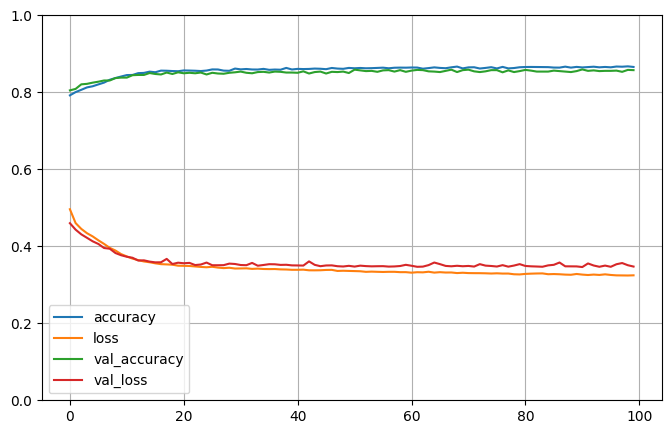

In [20]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [7]:
y_pred = model.predict(X_test)
y_pred.shape

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


(2000, 1)

In [8]:
y_pred[0]

array([0.08271529], dtype=float32)

In [11]:
y_pred = model.predict(X_test)
y_pred01 = y_pred.copy()
y_pred01[y_pred >= 0.5] = 1
y_pred01[y_pred < 0.5] = 0
print(confusion_matrix(y_test, y_pred01))
print(classification_report(y_test, y_pred01))
print(accuracy_score(y_test, y_pred01)) 

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[1549   47]
 [ 208  196]]
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1596
           1       0.81      0.49      0.61       404

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.76      2000
weighted avg       0.87      0.87      0.86      2000

0.8725


In [12]:
y_pred[0]

array([0.16806939], dtype=float32)

## Network 2

The network outputs 2 activation nodes (it is a binary classification) with softmax activation.

![](figures/neural2.png)

In [23]:
model = Sequential([
Input(shape=(X_train.shape[1],)),
Dense(100, activation="relu"),
Dense(2, activation="softmax")
])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 100)            │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │           202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,602 (6.26 KB)

 Trainable params: 1,602 (6.26 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
history = model.fit(X_train, y_train, epochs=100, validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5089 - val_loss: 0.4561
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4482 - val_loss: 0.4364
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4454 - val_loss: 0.4220
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4375 - val_loss: 0.4106
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4054 - val_loss: 0.4028
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4044 - val_loss: 0.4010
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3825 - val_loss: 0.3802
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3778 - val_loss: 0.3783
Epoch 9/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3675 - val_loss: 0.3794
Epoch 10/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3589 - val_loss: 0.3665
Epoch 11/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3525 - val_loss: 0.3616
Epoch 12/100
200/200 ━━━━━━━━━━━━━━━━━━━━

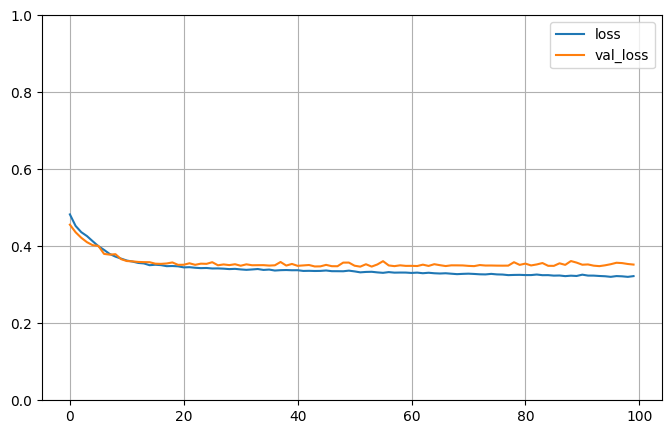

In [25]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [29]:
y_pred = model.predict(X_test)
y_pred = [np.argmax(p) for p in y_pred]
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 931us/step
[[1549   47]
 [ 217  187]]
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1596
           1       0.80      0.46      0.59       404

    accuracy                           0.87      2000
   macro avg       0.84      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



In [33]:
y_pred = model.predict(X_test)
y_pred[0]


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


array([0.64175683, 0.35824308], dtype=float32)

## Network 3

In this network we explore the case where y-values are one-hot encoded


In [34]:
y = pd.get_dummies(df['churn'], prefix='churn')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
y

,churn_0,churn_1
0,False,True
1,True,False
2,False,True
3,True,False
4,True,False
...,...,...
9995,True,False
9996,True,False
9997,False,True
9998,False,True


In [35]:
y_train

,churn_0,churn_1
532,True,False
8773,True,False
9868,True,False
9728,False,True
3449,True,False
...,...,...
3260,False,True
3187,True,False
8253,False,True
8232,True,False


In [36]:
from keras.models import Sequential
from keras.layers import Dense, Input


model = Sequential([
Input(shape=(X_train.shape[1],)),
Dense(100, activation="relu"),
Dense(2, activation="softmax")
])
model.compile(loss='categorical_crossentropy', optimizer='adam') # <----
history = model.fit(X_train, y_train, epochs=100, validation_split=0.2)


Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5029 - val_loss: 0.4366
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4662 - val_loss: 0.4156
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4394 - val_loss: 0.4052
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4289 - val_loss: 0.4047
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4163 - val_loss: 0.3899
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3996 - val_loss: 0.3786
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3938 - val_loss: 0.3718
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3821 - val_loss: 0.3796
Epoch 9/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3705 - val_loss: 0.3538
Epoch 10/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3696 - val_loss: 0.3444
Epoch 11/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3632 - val_loss: 0.3484
Epoch 12/100
200/200 ━━━━━━━━━━━━━━━━━━━━

In [38]:
y_pred = model.predict(X_test)
y_pred.shape

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


(2000, 2)

In [37]:
y_pred = model.predict(X_test)
y_pred = [np.argmax(p) for p in y_pred]
print(confusion_matrix(y_test['churn_1'], y_pred))
print(classification_report(y_test['churn_1'], y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
[[1472  102]
 [ 200  226]]
              precision    recall  f1-score   support

       False       0.88      0.94      0.91      1574
        True       0.69      0.53      0.60       426

    accuracy                           0.85      2000
   macro avg       0.78      0.73      0.75      2000
weighted avg       0.84      0.85      0.84      2000



## Network 4

In this network we add some balancing among training examples, and a call back to stop training is the model does not improve.
We also add a layer to the network

In [39]:
X = df.drop(['churn'], axis='columns')
y = df['churn']
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [48]:
num_classes = 2
input_shape = (X_train.shape[1],)
model = Sequential([
Input(shape=input_shape),
Dense(100, activation="relu"),
Dense(100, activation="relu"),
Dense(num_classes, activation="softmax")
])

model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 100)            │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 2)              │           202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,702 (45.71 KB)

 Trainable params: 11,702 (45.71 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))
#class_weights = {0:0.1, 1:5}
class_weights


{0: np.float64(0.6278449223041909), 1: np.float64(2.4554941682013505)}

In [53]:
import keras

callbacks = [
    keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=20),
]


model.compile(loss='categorical_crossentropy', optimizer='adam')
history = model.fit(X_train, pd.get_dummies(y_train), epochs=100, validation_split=0.2, class_weight=class_weights, callbacks=callbacks)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4081 - val_loss: 0.5551
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3964 - val_loss: 0.4481
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4015 - val_loss: 0.4380
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3885 - val_loss: 0.5026
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3868 - val_loss: 0.4725
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3828 - val_loss: 0.5272
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3901 - val_loss: 0.4985
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3918 - val_loss: 0.4300
Epoch 9/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3674 - val_loss: 0.4427
Epoch 10/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3737 - val_loss: 0.4967
Epoch 11/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3700 - val_loss: 0.4912
Epoch 12/100
200/200 ━━━━━━━━━━━━━━━━━━━━

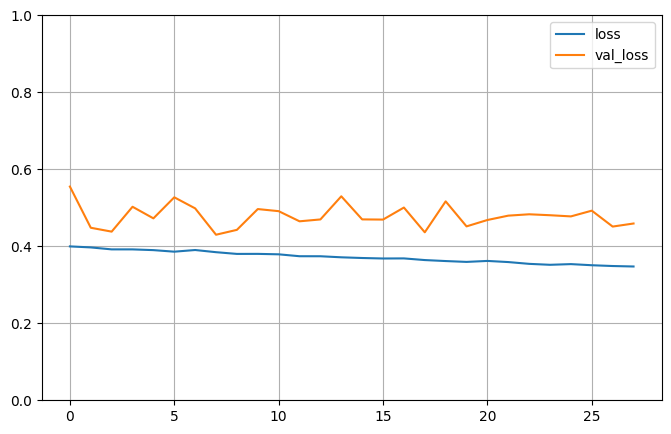

In [69]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [52]:
y_pred = model.predict(X_test)
#y_pred[y_pred >= 0.5] = 1
#y_pred[y_pred < 0.5] = 0
y_pred = [np.argmax(p) for p in y_pred]
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
[[1312  280]
 [ 117  291]]
              precision    recall  f1-score   support

           0       0.92      0.82      0.87      1592
           1       0.51      0.71      0.59       408

    accuracy                           0.80      2000
   macro avg       0.71      0.77      0.73      2000
weighted avg       0.83      0.80      0.81      2000

